In [1]:
import os
import math
import warnings
from pathlib import Path
import random


import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()} | MPS: {torch.backends.mps.is_available()}")

PyTorch 2.11.0 | CUDA: False | MPS: True


In [2]:
DATA_ROOT      = Path("./Data/training")
IMAGES_DIR     = DATA_ROOT / "Clean_Images"
TIMESERIES_DIR = DATA_ROOT / "Timeseries"
STRIPS_DIR     = DATA_ROOT / "Strips"
MASKS_DIR      = DATA_ROOT / "Masks"
CHUNKS_DIR     = DATA_ROOT / "Chunks"
CHECKPOINT_DIR = Path("./checkpoints")

BLACK_THRESHOLD     = 80
CAL_SPIKE_THRESHOLD = 25
LEFT_PCT            = 0.10
MIN_INTER_STRIP_GAP = 150
HEADER_GAP_RATIO    = 3.0
PADDING             = 20
COL_SPIKE_THRESHOLD = 50
MIN_CONSECUTIVE     = 6

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"Using device: {DEVICE}")


Using device: mps


In [3]:
def detect_signal_bands(img, target_bands=4):
    h, w = img.shape[:2]

    # Isolate left region where calibration pulse lives
    left = img[:, :int(w * LEFT_PCT)]
    b, g, r = cv2.split(left)
    black_mask = (r < BLACK_THRESHOLD) & (g < BLACK_THRESHOLD) & (b < BLACK_THRESHOLD)
    row_sums = black_mask.sum(axis=1).astype(float)

    # Subtract 1 to ignore the left border line
    row_sums = np.maximum(row_sums - 1, 0)
    spike_rows = np.where(row_sums > CAL_SPIKE_THRESHOLD)[0]

    # Group consecutive spike rows; take midpoint of each group as an anchor
    anchors = []
    if len(spike_rows) > 0:
        group_start = spike_rows[0]
        prev = spike_rows[0]
        for r_idx in spike_rows[1:]:
            if r_idx - prev > 5:
                anchors.append(int((group_start + prev) // 2))
                group_start = r_idx
            prev = r_idx
        anchors.append(int((group_start + prev) // 2))

    if len(anchors) < 2:
        return [(0, h)], anchors

    # Separate header anchors from signal anchors using gap ratio
    diffs = [anchors[i+1] - anchors[i] for i in range(len(anchors) - 1)]
    median_diff = np.median(diffs)
    header_cut = 0
    for i, d in enumerate(diffs):
        if d > median_diff * HEADER_GAP_RATIO:
            header_cut = i + 1
            break
    signal_anchors = anchors[header_cut:]

    # Merge anchors that are too close together
    strip_anchors = []
    prev = -MIN_INTER_STRIP_GAP
    for anchor in signal_anchors:
        if anchor - prev >= MIN_INTER_STRIP_GAP:
            strip_anchors.append(anchor)
            prev = anchor

    # Build band boundaries
    signal_bands = []
    for i, anchor in enumerate(strip_anchors):
        top = max(0, anchor - PADDING)
        bot = min(h, strip_anchors[i+1] - PADDING) if i+1 < len(strip_anchors) else h
        signal_bands.append((top, bot))

    # If too many bands, drop the shortest
    if len(signal_bands) > target_bands:
        ranked = sorted(signal_bands, key=lambda b: b[1] - b[0], reverse=True)
        kept = set(map(tuple, ranked[:target_bands]))
        signal_bands = [b for b in signal_bands if tuple(b) in kept]

    return signal_bands, strip_anchors


def split_ecg_strips(image_path, output_dir, target_bands=4):
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")
    signal_bands, _ = detect_signal_bands(img, target_bands=target_bands)
    os.makedirs(output_dir, exist_ok=True)
    stem = Path(image_path).stem
    saved = []
    for i, (y1, y2) in enumerate(signal_bands):
        out_path = os.path.join(output_dir, f"{stem}_strip_{i+1}.png")
        cv2.imwrite(out_path, img[y1:y2, :])
        saved.append(out_path)
    return saved


Split Strips

Found 600 images


Splitting strips:   0%|          | 0/600 [00:00<?, ?it/s]


Strip count distribution: {4: 600}
Errors: 0


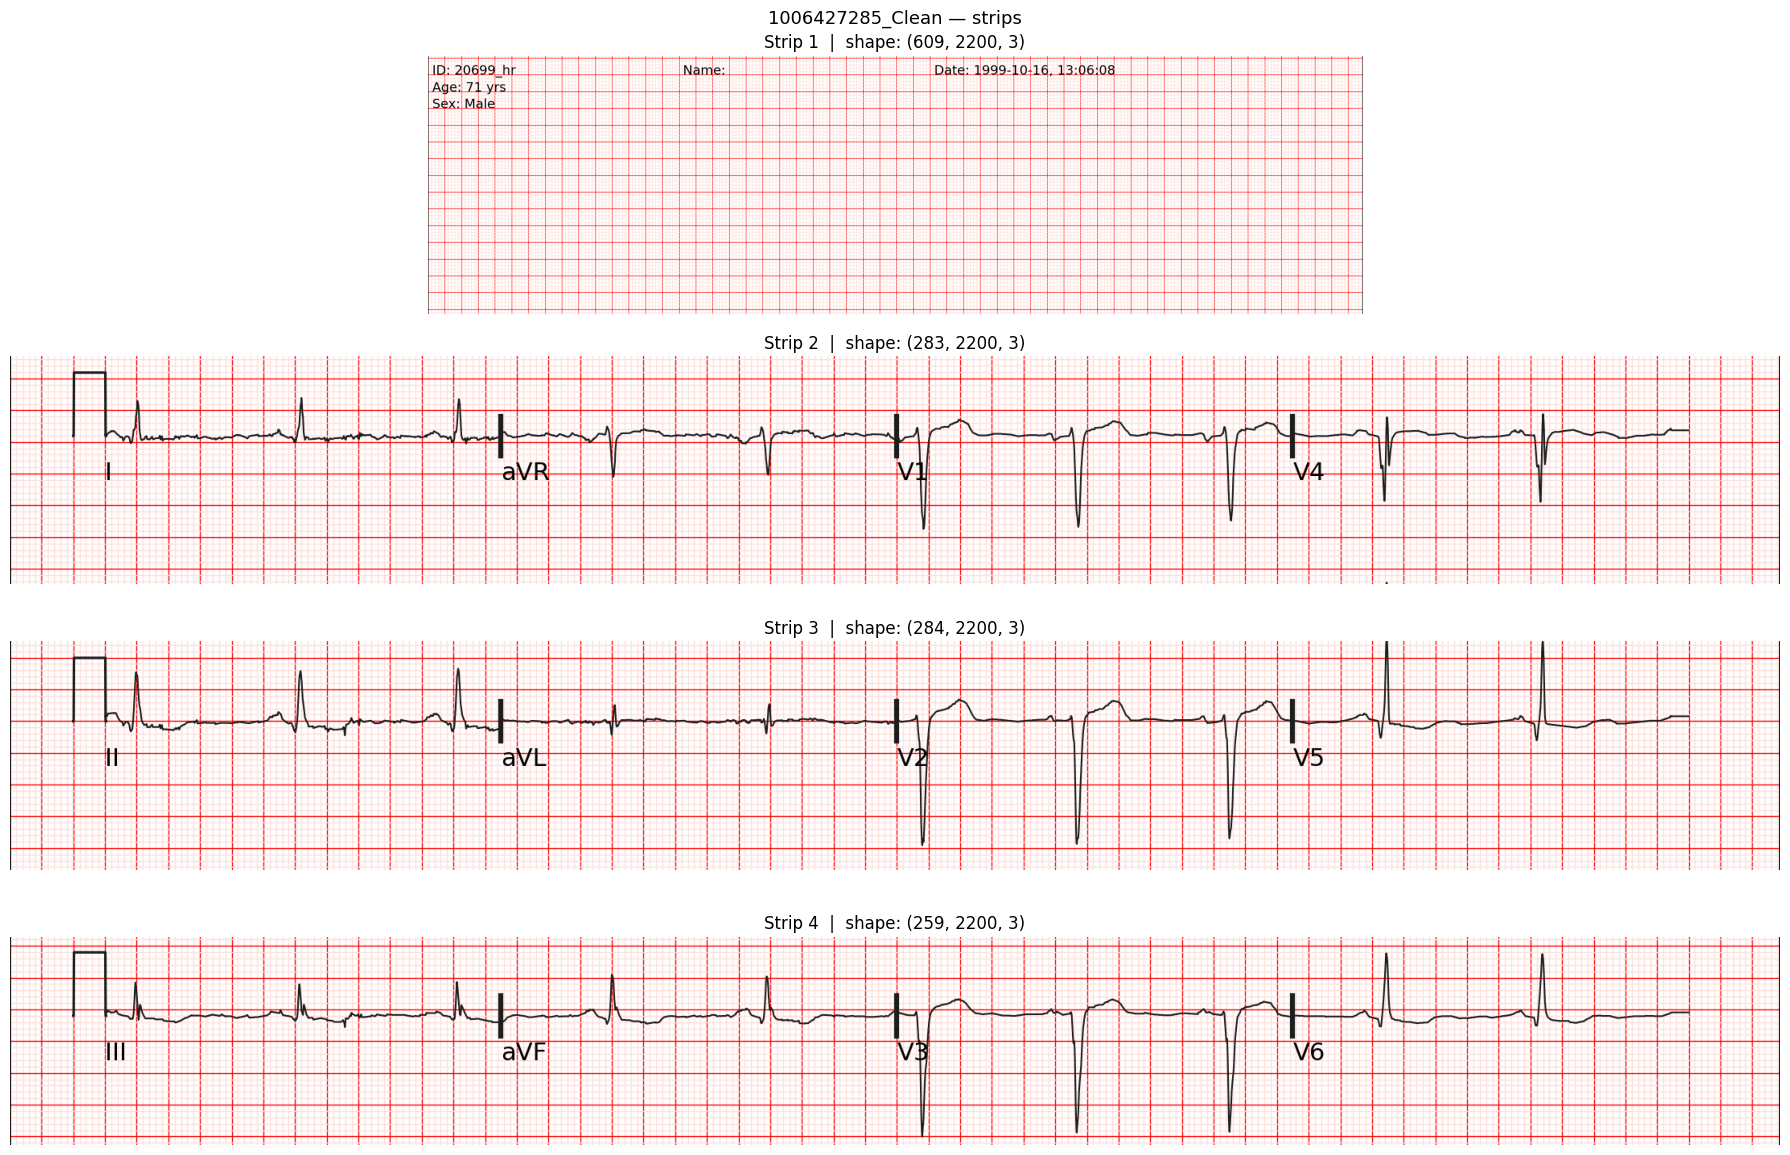

In [4]:
image_paths = sorted(list(IMAGES_DIR.glob("*.png")) + list(IMAGES_DIR.glob("*.jpg")))
print(f"Found {len(image_paths)} images")

errors = []
strip_counts = []
for img_path in tqdm(image_paths, desc="Splitting strips"):
    try:
        saved = split_ecg_strips(img_path, STRIPS_DIR)
        strip_counts.append(len(saved))
    except Exception as e:
        errors.append((img_path.name, str(e)))

print(f"\nStrip count distribution: {pd.Series(strip_counts).value_counts().to_dict()}")
print(f"Errors: {len(errors)}")
if errors:
    for name, err in errors[:5]:
        print(f"  {name}: {err}")

# Visual check
sample_path = image_paths[0]
strip_paths = sorted(STRIPS_DIR.glob(f"{sample_path.stem}_strip_*.png"))

fig, axes = plt.subplots(len(strip_paths), 1, figsize=(18, 3 * len(strip_paths)))
if len(strip_paths) == 1:
    axes = [axes]
fig.suptitle(f"{sample_path.stem} — strips", fontsize=13)
for i, sp in enumerate(strip_paths):
    strip_img = cv2.cvtColor(cv2.imread(str(sp)), cv2.COLOR_BGR2RGB)
    axes[i].imshow(strip_img)
    axes[i].set_title(f"Strip {i+1}  |  shape: {strip_img.shape}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

Split points: [609, 1101, 1592]  (expected 3)


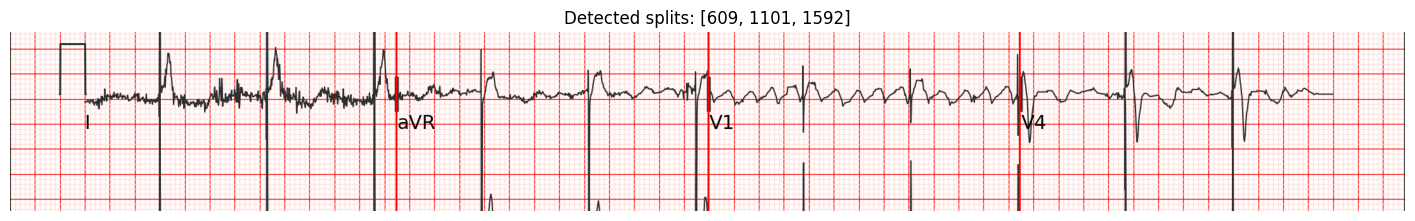

In [5]:
def find_split_points(strip):
    h, w = strip.shape[:2]
    b, g, r = cv2.split(strip)
    is_black = (r < BLACK_THRESHOLD) & (g < BLACK_THRESHOLD) & (b < BLACK_THRESHOLD)
    col_sums = is_black.sum(axis=0).astype(float)

    spike_cols = np.where(col_sums > 50)[0]

    # Group consecutive columns
    groups = []
    if len(spike_cols) > 0:
        group = [spike_cols[0]]
        for col in spike_cols[1:]:
            if col == group[-1] + 1:
                group.append(col)
            else:
                groups.append(group)
                group = [col]
        groups.append(group)

    # Filter obvious non-separators: borders, too narrow, too tall
    candidates = []
    for group in groups:
        width   = len(group)
        center  = int(np.mean(group))
        max_sum = col_sums[group].max()
        if width >= MIN_CONSECUTIVE and center > 10 and center < w - 10 and max_sum < 250:
            candidates.append((center, max_sum, width))

    if len(candidates) == 0:
        return []

    # We always expect 3 separators roughly evenly spaced at w/4, w/2, 3w/4
    # Score each candidate by how close it is to the expected positions
    expected = [w * 0.25, w * 0.50, w * 0.75]

    if len(candidates) >= 3:
        # Pick the best candidate for each expected position
        split_points = []
        used = set()
        for exp_x in expected:
            best = min(
                [c for i, c in enumerate(candidates) if i not in used],
                key=lambda c: abs(c[0] - exp_x)
            )
            idx = candidates.index(best)
            used.add(idx)
            split_points.append(best[0])
        return sorted(split_points)

    # Too few candidates — fall back to returning what we have
    return sorted([c[0] for c in candidates])

# Visual check
sample_strip_path = Path('Data/training/Strips/4267219232_Clean_strip_1.png') #random.choice(sorted(STRIPS_DIR.glob("*_strip_1.png"))) 
sample_strip      = cv2.imread(str(sample_strip_path))
split_points      = find_split_points(sample_strip)
print(f"Split points: {split_points}  (expected 3)")

vis = cv2.cvtColor(sample_strip, cv2.COLOR_BGR2RGB).copy()
for x in split_points:
    vis[:, max(0,x-1):x+2] = [255, 0, 0]

plt.figure(figsize=(18, 4))
plt.imshow(vis)
plt.title(f"Detected splits: {split_points}")
plt.axis("off")
plt.show()

In [6]:
COLOUR_CHUNKS_DIR = DATA_ROOT / "Colour_Chunks"
COLOUR_CHUNKS_DIR.mkdir(parents=True, exist_ok=True)

errors = []
total  = 0
for strip_path in tqdm(sorted(STRIPS_DIR.glob("*.png")), desc="Saving colour chunks"):
    strip_idx = int(strip_path.stem.split("_strip_")[1])
    if strip_idx == 4:
        continue

    strip        = cv2.imread(str(strip_path))
    split_points = find_split_points(strip)

    if len(split_points) != 3:
        errors.append((strip_path.name, f"got {len(split_points)} split points"))
        continue

    bounds = [0] + split_points + [strip.shape[1]]
    stem   = strip_path.stem
    for i in range(len(bounds) - 1):
        x1, x2   = bounds[i], bounds[i+1]
        chunk     = strip[:, x1:x2]
        out_path  = COLOUR_CHUNKS_DIR / f"{stem}_chunk_{i+1}.png"
        cv2.imwrite(str(out_path), chunk)
        total += 1

print(f"Saved {total} colour chunks")
print(f"Errors: {len(errors)}")

Saving colour chunks:   0%|          | 0/2400 [00:00<?, ?it/s]

Saved 7068 colour chunks
Errors: 33


Found 4 strips


Cropping chunks:   0%|          | 0/1767 [00:00<?, ?it/s]


Saved 1669 cropped chunks to Data/training/Colour_Chunks
Errors: 98
  1048962695_Clean_strip_3_chunk_1.png: Not enough spike cols
  1103158012_Clean_strip_3_chunk_1.png: Not enough spike cols
  1151562032_Clean_strip_3_chunk_1.png: Not enough spike cols
  1154001412_Clean_strip_3_chunk_1.png: Not enough spike cols
  1163641242_Clean_strip_3_chunk_1.png: Not enough spike cols
  1174117563_Clean_strip_3_chunk_1.png: Not enough spike cols
  1254751446_Clean_strip_3_chunk_1.png: Not enough spike cols
  1289824484_Clean_strip_3_chunk_1.png: Not enough spike cols
  133948617_Clean_strip_3_chunk_1.png: Not enough spike cols
  145399852_Clean_strip_3_chunk_1.png: Not enough spike cols


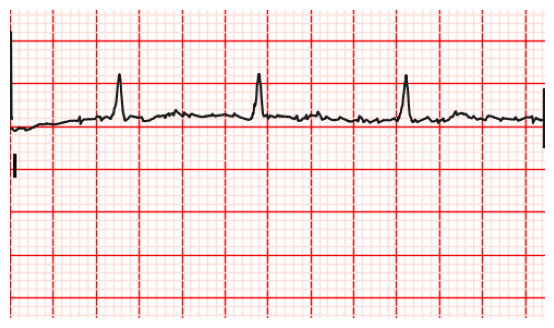

In [7]:
def crop_left_edge(chunk_path):
    
    chunk = cv2.imread(str(chunk_path))

    b, g, r = cv2.split(chunk)
    is_black = (r < BLACK_THRESHOLD) & (g < BLACK_THRESHOLD) & (b < BLACK_THRESHOLD)
    col_sums = is_black.sum(axis=0).astype(float)

    spike_cols = np.where(col_sums > 80)[0]
    if len(spike_cols) <= 3:
        return None, "Not enough spike cols"
    # if len(spike_cols) == 2:
    #     crop_point = spike_cols[1]
    #     print("Too few spike_cols")
    else:
        crop_point = spike_cols[3]

    
    cropped_chunk = chunk[:, crop_point:]
    cv2.imwrite(str(chunk_path), cropped_chunk)
    return(str(chunk_path), None)



# Run on all strips
chunk1s = sorted(COLOUR_CHUNKS_DIR.glob("*_chunk_1.png"))
print(f"Found {len(strip_paths)} strips")

errors = []
total  = 0
for strip_path in tqdm(chunk1s, desc="Cropping chunks"):
    saved, err = crop_left_edge(strip_path)
    if err:
        errors.append((strip_path.name, err))
    else:
        total += 1

print(f"\nSaved {total} cropped chunks to {COLOUR_CHUNKS_DIR}")
print(f"Errors: {len(errors)}")
if errors:
    for name, err in errors[:10]:
        print(f"  {name}: {err}")
# Visual check
sample_strip_path = random.choice(sorted(COLOUR_CHUNKS_DIR.glob("*_strip_1_chunk_1.png")))
sample_strip      = cv2.imread(str(sample_strip_path))
vis = cv2.cvtColor(sample_strip, cv2.COLOR_BGR2RGB).copy()


plt.figure(figsize=(18, 4))
plt.imshow(vis)
plt.axis("off")
plt.show()

Found 4 strips


Cropping chunks:   0%|          | 0/1767 [00:00<?, ?it/s]


Saved 1767 cropped chunks to Data/training/Colour_Chunks
Errors: 0


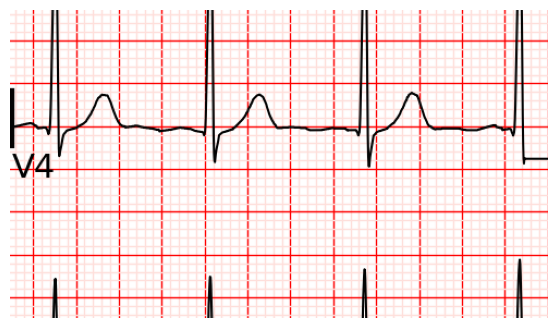

In [8]:
def crop_right_edge(chunk_path):
    
    chunk = cv2.imread(str(chunk_path))

    b, g, r = cv2.split(chunk)
    is_black = (r < BLACK_THRESHOLD) & (g < BLACK_THRESHOLD) & (b < BLACK_THRESHOLD)
    col_sums = is_black.sum(axis=0).astype(float)

    blank_cols = np.where(col_sums == 0)[0]

    # Group consecutive blank columns, looking for only groups with length at least 25
    groups = []
    if len(blank_cols) > 0:
        group = [blank_cols[0]]
        for col in blank_cols[1:]:
            if col == group[-1] + 1:
                group.append(col)
            else:
                if len(group) >= 25:
                    groups.append(group)
                group = [col]
        if len(group) >= 25:
            groups.append(group)
    
    #take the first value of the first group
    if len (groups) < 1:
        return None, "No blank sections"
    crop_point = groups[0][0]



    
    cropped_chunk = chunk[:, :crop_point]

    cv2.imwrite(str(chunk_path), cropped_chunk)
    return(str(chunk_path), None)


# Run on all strips
chunk4s = sorted(COLOUR_CHUNKS_DIR.glob("*_chunk_4.png"))
print(f"Found {len(strip_paths)} strips")

errors = []
total  = 0
for strip_path in tqdm(chunk4s, desc="Cropping chunks"):
    saved, err = crop_right_edge(strip_path)
    if err:
        errors.append((strip_path.name, err))
    else:
        total += 1

print(f"\nSaved {total} cropped chunks to {COLOUR_CHUNKS_DIR}")
print(f"Errors: {len(errors)}")
if errors:
    for name, err in errors[:10]:
        print(f"  {name}: {err}")
# Visual check
sample_strip_path = random.choice(sorted(COLOUR_CHUNKS_DIR.glob("*_strip_1_chunk_4.png")))
sample_strip      = cv2.imread(str(sample_strip_path))
vis = cv2.cvtColor(sample_strip, cv2.COLOR_BGR2RGB).copy()


plt.figure(figsize=(18, 4))
plt.imshow(vis)
plt.axis("off")
plt.show()

In [9]:
chunk_to_lead = {"strip_1_chunk_1": "I", "strip_1_chunk_2": "aVR", "strip_1_chunk_3": "V1", "strip_1_chunk_4": "V4", 
                 "strip_2_chunk_1": "II", "strip_2_chunk_2": "aVL", "strip_2_chunk_3": "V2", "strip_2_chunk_4": "V5",
                 "strip_3_chunk_1": "III", "strip_3_chunk_2": "aVF", "strip_3_chunk_3" :"V3", "strip_3_chunk_4": "V6"}


In [10]:
chunk_paths = sorted(COLOUR_CHUNKS_DIR.glob("*.png"))
print(f"Total chunks: {len(chunk_paths)}")

# Count successful records (those with all 12 chunks: 3 strips x 4 chunks)
from collections import defaultdict
record_chunks = defaultdict(int)
for cp in chunk_paths:
    # e.g. 32650710_Clean_strip_1_mask_chunk_1.png
    record_id = cp.stem.split("_Clean")[0]
    record_chunks[record_id] += 1

counts = pd.Series(record_chunks.values())
print(f"\nChunk count distribution per record:")
print(counts.value_counts().sort_index())
print(f"\nRecords with all 12 chunks: {(counts == 12).sum()}")
print(f"Total records: {len(record_chunks)}")

Total chunks: 7068

Chunk count distribution per record:
4       1
8      31
12    568
Name: count, dtype: int64

Records with all 12 chunks: 568
Total records: 600


In [11]:
training_csv_dict = {}
for chunk in chunk_to_lead.keys():
    lead = chunk_to_lead[chunk]
    rows = []
    for chunk_path in sorted(COLOUR_CHUNKS_DIR.glob("*_"+ chunk + ".png")):
        record_id = chunk_path.stem.split("_Clean")[0]
        csv_path  = TIMESERIES_DIR / f"{record_id}.csv"
        if not csv_path.exists():
            continue
        if record_chunks[record_id] != 12:
            continue
        rows.append({
            "chunk_path": str(chunk_path),
            "lead":       lead,
            "record_id":  record_id,
            "csv_path":   str(csv_path),
        })

    index_df = pd.DataFrame(rows)
    print(f"Samples for lead {lead}: {len(index_df)}")
    training_csv_dict[lead] = index_df
training_csv_dict["aVR"].head()

Samples for lead I: 568
Samples for lead aVR: 568
Samples for lead V1: 568
Samples for lead V4: 568
Samples for lead II: 568
Samples for lead aVL: 568
Samples for lead V2: 568
Samples for lead V5: 568
Samples for lead III: 568
Samples for lead aVF: 568
Samples for lead V3: 568
Samples for lead V6: 568


,chunk_path,lead,record_id,csv_path
0,Data/training/Colour_Chunks/1015663939_Clean_s...,aVR,1015663939,Data/training/Timeseries/1015663939.csv
1,Data/training/Colour_Chunks/1041099777_Clean_s...,aVR,1041099777,Data/training/Timeseries/1041099777.csv
2,Data/training/Colour_Chunks/1048962695_Clean_s...,aVR,1048962695,Data/training/Timeseries/1048962695.csv
3,Data/training/Colour_Chunks/1052007218_Clean_s...,aVR,1052007218,Data/training/Timeseries/1052007218.csv
4,Data/training/Colour_Chunks/1059602762_Clean_s...,aVR,1059602762,Data/training/Timeseries/1059602762.csv


Also crop the lead II ones

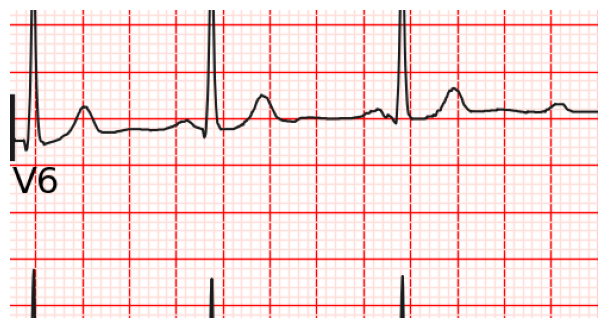

In [12]:
sample_strip_path = strip_path
sample_strip      = cv2.imread(str(sample_strip_path))
vis = cv2.cvtColor(sample_strip, cv2.COLOR_BGR2RGB).copy()


plt.figure(figsize=(18, 4))
plt.imshow(vis)
plt.axis("off")
plt.show()

Found 600 strips


Cropping left:   0%|          | 0/600 [00:00<?, ?it/s]

Cropping right:   0%|          | 0/600 [00:00<?, ?it/s]


Saved 595 cropped chunks to Data/training/Strips
Errors: 5
  1436234058_Clean_strip_4.png: No blank sections
  2566168201_Clean_strip_4.png: No blank sections
  2932215077_Clean_strip_4.png: No blank sections
  3355417892_Clean_strip_4.png: No blank sections
  4289880010_Clean_strip_4.png: No blank sections


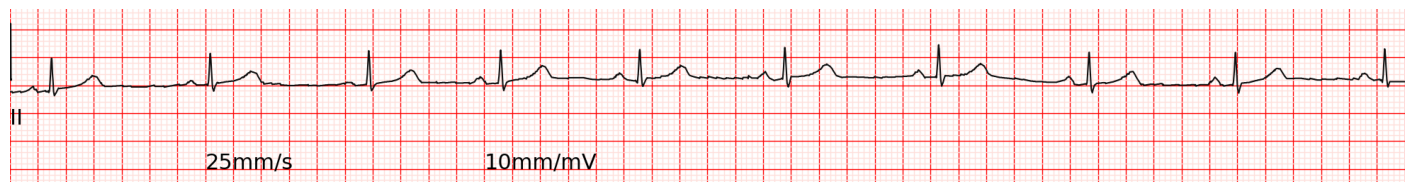

In [13]:
strip4s = sorted(STRIPS_DIR.glob("*_strip_4.png"))
print(f"Found {len(strip4s)} strips")

errors = []
for strip_path in tqdm(strip4s, desc="Cropping left"):
    saved, err = crop_left_edge(strip_path)
    if err:
        errors.append((strip_path.name, err))

errorless = []     
for strip_path in tqdm(strip4s, desc="Cropping right"):
    saved, err = crop_right_edge(strip_path)
    if err:
        errors.append((strip_path.name, err))
    else:
        errorless.append(strip_path)



print(f"\nSaved {len(errorless)} cropped chunks to {STRIPS_DIR}")
print(f"Errors: {len(errors)}")
if errors:
    for name, err in errors[:10]:
        print(f"  {name}: {err}")
# Visual check
sample_strip_path = random.choice(sorted(STRIPS_DIR.glob("*_strip_4.png")))
sample_strip      = cv2.imread(str(sample_strip_path))
vis = cv2.cvtColor(sample_strip, cv2.COLOR_BGR2RGB).copy()


plt.figure(figsize=(18, 4))
plt.imshow(vis)
plt.axis("off")
plt.show()

In [14]:

rows = []
for chunk_path in errorless:
    record_id = chunk_path.stem.split("_Clean")[0]
    csv_path  = TIMESERIES_DIR / f"{record_id}.csv"
    if not csv_path.exists():
        continue
    if record_chunks[record_id] != 12:
        continue
    rows.append({
        "chunk_path": str(chunk_path),
        "lead":       "II",
        "record_id":  record_id,
        "csv_path":   str(csv_path),
    })

index_df = pd.DataFrame(rows)
print(f"Training Samples for lead II: {len(index_df)}")
training_csv_dict["II"] = index_df


Training Samples for lead II: 568


Check shapes of all the different images

In [15]:
for chunk in chunk_to_lead:
    lead = chunk_to_lead[chunk]
    shapes = [cv2.imread(path).shape for path in training_csv_dict[lead]["chunk_path"]]
    heights = [shape[0] for shape in shapes]
    widths = [shape[1] for shape in shapes]
    print(f"Mean {lead} height: {np.mean(heights)}; mean {lead} width: {np.mean(widths)}: chunk is {chunk}")


Mean I height: 283.0; mean I width: 490.9964788732394: chunk is strip_1_chunk_1
Mean aVR height: 283.0; mean aVR width: 492.01056338028167: chunk is strip_1_chunk_2
Mean V1 height: 283.0; mean V1 width: 493.77464788732397: chunk is strip_1_chunk_3
Mean V4 height: 283.0; mean V4 width: 491.3116197183099: chunk is strip_1_chunk_4
Mean II height: 244.0; mean II width: 1968.9242957746478: chunk is strip_2_chunk_1
Mean aVL height: 283.85035211267603; mean aVL width: 492.03169014084506: chunk is strip_2_chunk_2
Mean V2 height: 283.85035211267603; mean V2 width: 492.40845070422534: chunk is strip_2_chunk_3
Mean V5 height: 283.85035211267603; mean V5 width: 493.44542253521126: chunk is strip_2_chunk_4
Mean III height: 259.14964788732397; mean III width: 510.14084507042253: chunk is strip_3_chunk_1
Mean aVF height: 259.14964788732397; mean aVF width: 492.03169014084506: chunk is strip_3_chunk_2
Mean V3 height: 259.14964788732397; mean V3 width: 492.03169014084506: chunk is strip_3_chunk_3
Mean 

Get and appropriately crop validation data

In [16]:
VAL_DATA_ROOT      = Path("./Data/Development")
VAL_IMAGES_DIR     = VAL_DATA_ROOT / "Clean_Images"
VAL_TIMESERIES_DIR = VAL_DATA_ROOT / "Timeseries"
VAL_STRIPS_DIR     = VAL_DATA_ROOT / "Strips"
VAL_MASKS_DIR      = VAL_DATA_ROOT / "Masks"
VAL_CHUNKS_DIR     = VAL_DATA_ROOT / "Chunks"



Found 150 images


Splitting strips:   0%|          | 0/150 [00:00<?, ?it/s]


Strip count distribution: {4: 150}
Errors: 0


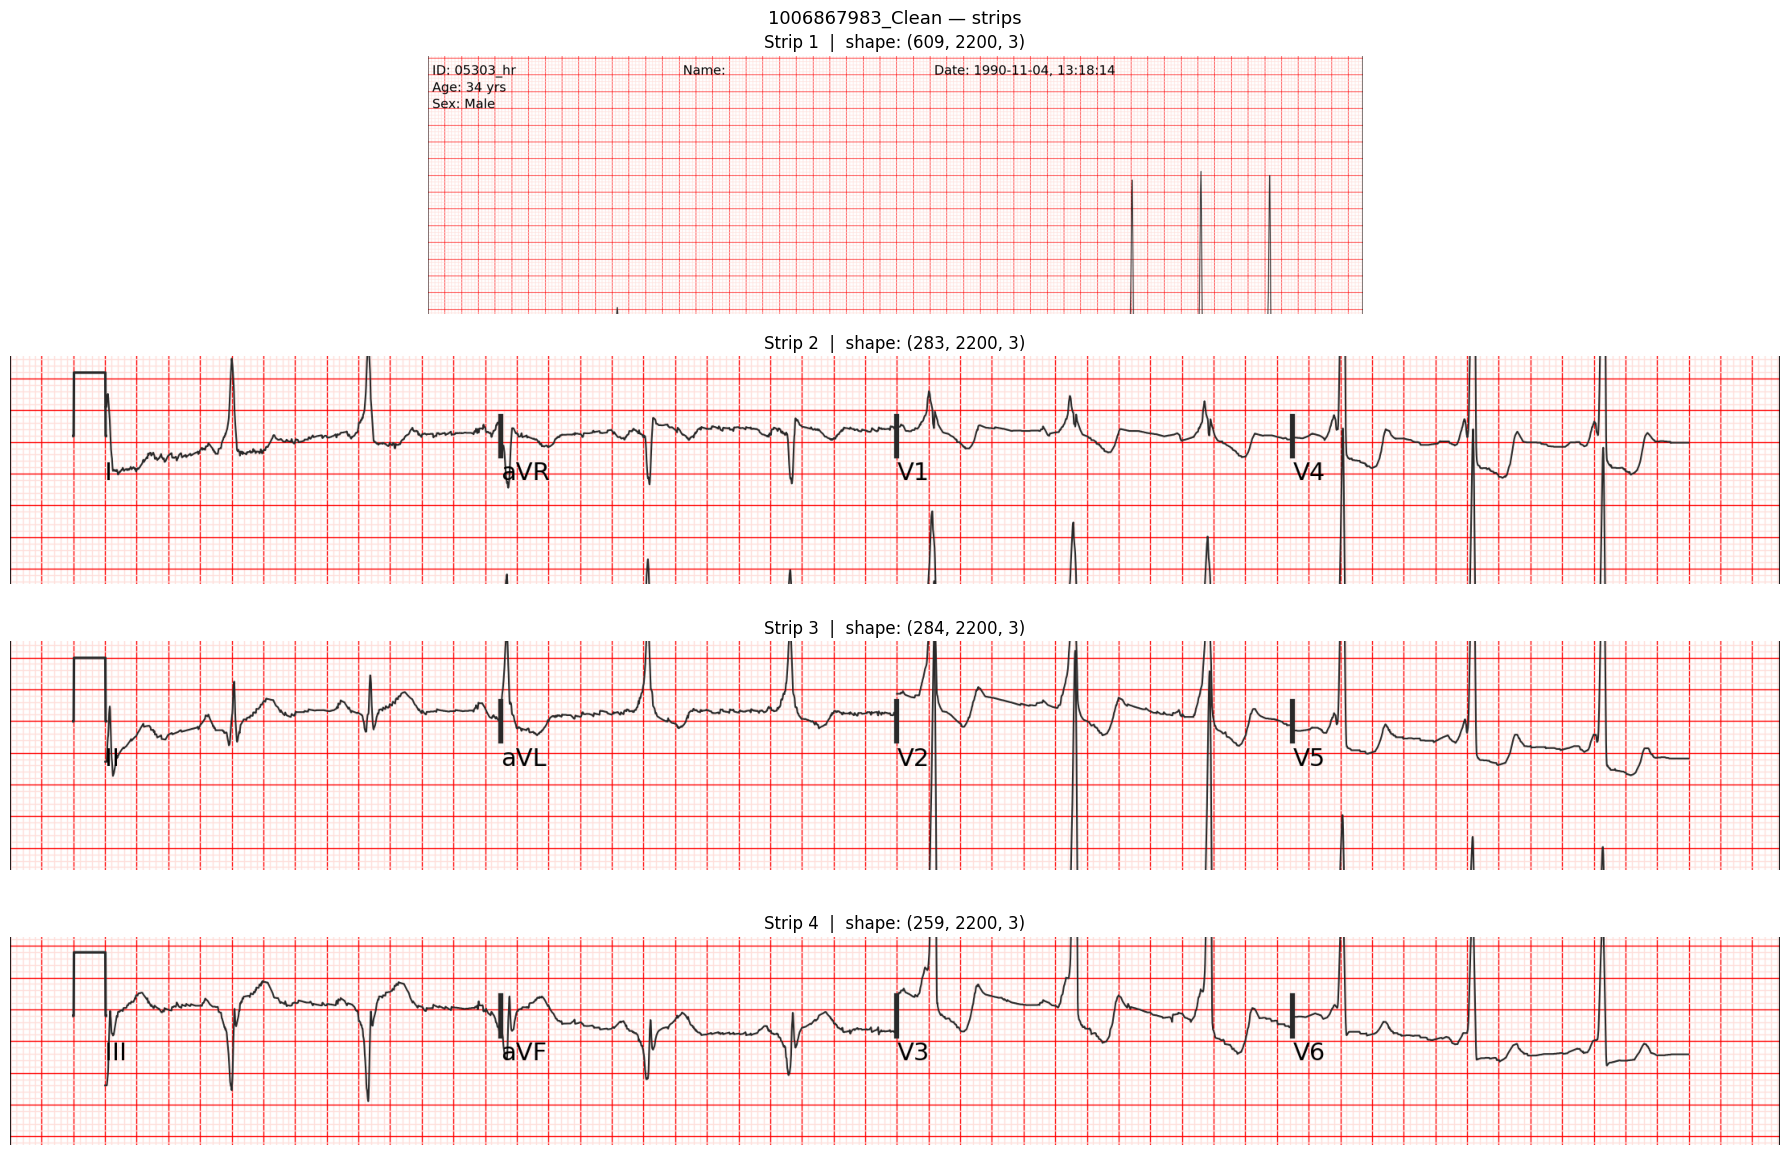

In [17]:
image_paths = sorted(list(VAL_IMAGES_DIR.glob("*.png")) + list(VAL_IMAGES_DIR.glob("*.jpg")))
print(f"Found {len(image_paths)} images")

errors = []
strip_counts = []
for img_path in tqdm(image_paths, desc="Splitting strips"):
    try:
        saved = split_ecg_strips(img_path, VAL_STRIPS_DIR)
        strip_counts.append(len(saved))
    except Exception as e:
        errors.append((img_path.name, str(e)))

print(f"\nStrip count distribution: {pd.Series(strip_counts).value_counts().to_dict()}")
print(f"Errors: {len(errors)}")
if errors:
    for name, err in errors[:5]:
        print(f"  {name}: {err}")

# Visual check
sample_path = image_paths[0]
strip_paths = sorted(VAL_STRIPS_DIR.glob(f"{sample_path.stem}_strip_*.png"))

fig, axes = plt.subplots(len(strip_paths), 1, figsize=(18, 3 * len(strip_paths)))
if len(strip_paths) == 1:
    axes = [axes]
fig.suptitle(f"{sample_path.stem} — strips", fontsize=13)
for i, sp in enumerate(strip_paths):
    strip_img = cv2.cvtColor(cv2.imread(str(sp)), cv2.COLOR_BGR2RGB)
    axes[i].imshow(strip_img)
    axes[i].set_title(f"Strip {i+1}  |  shape: {strip_img.shape}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [18]:
VAL_COLOUR_CHUNKS_DIR = VAL_DATA_ROOT / "Colour_Chunks"
VAL_COLOUR_CHUNKS_DIR.mkdir(parents=True, exist_ok=True)

errors = []
total  = 0
for strip_path in tqdm(sorted(VAL_STRIPS_DIR.glob("*.png")), desc="Saving colour chunks"):
    strip_idx = int(strip_path.stem.split("_strip_")[1])
    if strip_idx == 4:
        continue

    strip        = cv2.imread(str(strip_path))
    split_points = find_split_points(strip)

    if len(split_points) != 3:
        errors.append((strip_path.name, f"got {len(split_points)} split points"))
        continue

    bounds = [0] + split_points + [strip.shape[1]]
    stem   = strip_path.stem
    for i in range(len(bounds) - 1):
        x1, x2   = bounds[i], bounds[i+1]
        chunk     = strip[:, x1:x2]
        out_path  = VAL_COLOUR_CHUNKS_DIR / f"{stem}_chunk_{i+1}.png"
        cv2.imwrite(str(out_path), chunk)
        total += 1

print(f"Saved {total} colour chunks")
print(f"Errors: {len(errors)}")

Saving colour chunks:   0%|          | 0/600 [00:00<?, ?it/s]

Saved 1772 colour chunks
Errors: 7


In [19]:
val_chunk_paths = sorted(VAL_COLOUR_CHUNKS_DIR.glob("*.png"))
print(f"Total chunks: {len(val_chunk_paths)}")

# Count successful records (those with all 12 chunks: 3 strips x 4 chunks)
from collections import defaultdict
val_record_chunks = defaultdict(int)
for cp in val_chunk_paths:
    # e.g. 32650710_Clean_strip_1_mask_chunk_1.png
    record_id = cp.stem.split("_Clean")[0]
    val_record_chunks[record_id] += 1

counts = pd.Series(val_record_chunks.values())
print(f"\nChunk count distribution per record:")
print(counts.value_counts().sort_index())
print(f"\nRecords with all 12 chunks: {(counts == 12).sum()}")
print(f"Total records: {len(val_record_chunks)}")

Total chunks: 1772

Chunk count distribution per record:
8       7
12    143
Name: count, dtype: int64

Records with all 12 chunks: 143
Total records: 150


In [20]:
chunk1s = sorted(VAL_COLOUR_CHUNKS_DIR.glob("*_chunk_1.png"))
print(f"Found {len(strip_paths)} strips")

errors = []
total  = 0
for strip_path in tqdm(chunk1s, desc="Cropping chunks"):
    saved, err = crop_left_edge(strip_path)
    if err:
        errors.append((strip_path.name, err))
    else:
        total += 1

print(f"\nSaved {total} cropped chunks to {VAL_COLOUR_CHUNKS_DIR}")
print(f"Errors: {len(errors)}")
if errors:
    for name, err in errors[:10]:
        print(f"  {name}: {err}")


chunk4s = sorted(VAL_COLOUR_CHUNKS_DIR.glob("*_chunk_4.png"))
print(f"Found {len(strip_paths)} strips")

errors = []
total  = 0
for strip_path in tqdm(chunk4s, desc="Cropping chunks"):
    saved, err = crop_right_edge(strip_path)
    if err:
        errors.append((strip_path.name, err))
    else:
        total += 1

print(f"\nSaved {total} cropped chunks to {VAL_COLOUR_CHUNKS_DIR}")
print(f"Errors: {len(errors)}")
if errors:
    for name, err in errors[:10]:
        print(f"  {name}: {err}")


Found 4 strips


Cropping chunks:   0%|          | 0/443 [00:00<?, ?it/s]


Saved 421 cropped chunks to Data/Development/Colour_Chunks
Errors: 22
  1531629157_Clean_strip_3_chunk_1.png: Not enough spike cols
  1678324396_Clean_strip_3_chunk_1.png: Not enough spike cols
  1868006986_Clean_strip_3_chunk_1.png: Not enough spike cols
  198290386_Clean_strip_3_chunk_1.png: Not enough spike cols
  1998779717_Clean_strip_3_chunk_1.png: Not enough spike cols
  2089312114_Clean_strip_3_chunk_1.png: Not enough spike cols
  2461704588_Clean_strip_3_chunk_1.png: Not enough spike cols
  2546276044_Clean_strip_3_chunk_1.png: Not enough spike cols
  2589114748_Clean_strip_3_chunk_1.png: Not enough spike cols
  2711409608_Clean_strip_3_chunk_1.png: Not enough spike cols
Found 4 strips


Cropping chunks:   0%|          | 0/443 [00:00<?, ?it/s]


Saved 442 cropped chunks to Data/Development/Colour_Chunks
Errors: 1
  1006867983_Clean_strip_1_chunk_4.png: No blank sections


Found 150 strips


Cropping left:   0%|          | 0/150 [00:00<?, ?it/s]

Cropping right:   0%|          | 0/150 [00:00<?, ?it/s]


Saved 150 cropped chunks to Data/Development/Strips
Errors: 0


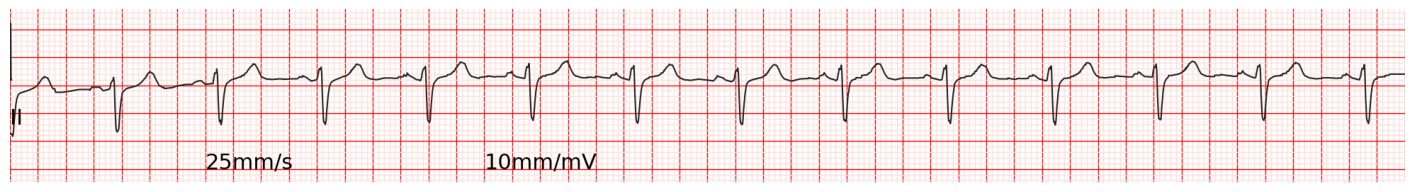

In [21]:
strip4s = sorted(VAL_STRIPS_DIR.glob("*_strip_4.png"))
print(f"Found {len(strip4s)} strips")

errors = []
for strip_path in tqdm(strip4s, desc="Cropping left"):
    saved, err = crop_left_edge(strip_path)
    if err:
        errors.append((strip_path.name, err))

errorless = []     
for strip_path in tqdm(strip4s, desc="Cropping right"):
    saved, err = crop_right_edge(strip_path)
    if err:
        errors.append((strip_path.name, err))
    else:
        errorless.append(strip_path)



print(f"\nSaved {len(errorless)} cropped chunks to {VAL_STRIPS_DIR}")
print(f"Errors: {len(errors)}")
if errors:
    for name, err in errors[:10]:
        print(f"  {name}: {err}")
# Visual check
sample_strip_path = random.choice(sorted(VAL_STRIPS_DIR.glob("*_strip_4.png")))
sample_strip      = cv2.imread(str(sample_strip_path))
vis = cv2.cvtColor(sample_strip, cv2.COLOR_BGR2RGB).copy()


plt.figure(figsize=(18, 4))
plt.imshow(vis)
plt.axis("off")
plt.show()

In [22]:
development_csv_dict = {}
for chunk in chunk_to_lead.keys():
    lead = chunk_to_lead[chunk]
    rows = []
    for chunk_path in sorted(VAL_COLOUR_CHUNKS_DIR.glob("*_"+ chunk + ".png")):
        record_id = chunk_path.stem.split("_Clean")[0]
        csv_path  = VAL_TIMESERIES_DIR / f"{record_id}.csv"
        if not csv_path.exists():
            continue
        if val_record_chunks[record_id] != 12:
            continue
        rows.append({
            "chunk_path": str(chunk_path),
            "lead":       lead,
            "record_id":  record_id,
            "csv_path":   str(csv_path),
        })

    index_df = pd.DataFrame(rows)
    print(f"Samples for lead {lead}: {len(index_df)}")
    development_csv_dict[lead] = index_df
development_csv_dict["aVR"].head()

Samples for lead I: 143
Samples for lead aVR: 143
Samples for lead V1: 143
Samples for lead V4: 143
Samples for lead II: 143
Samples for lead aVL: 143
Samples for lead V2: 143
Samples for lead V5: 143
Samples for lead III: 143
Samples for lead aVF: 143
Samples for lead V3: 143
Samples for lead V6: 143


,chunk_path,lead,record_id,csv_path
0,Data/Development/Colour_Chunks/1006867983_Clea...,aVR,1006867983,Data/Development/Timeseries/1006867983.csv
1,Data/Development/Colour_Chunks/104573050_Clean...,aVR,104573050,Data/Development/Timeseries/104573050.csv
2,Data/Development/Colour_Chunks/1063816858_Clea...,aVR,1063816858,Data/Development/Timeseries/1063816858.csv
3,Data/Development/Colour_Chunks/108599929_Clean...,aVR,108599929,Data/Development/Timeseries/108599929.csv
4,Data/Development/Colour_Chunks/1135737846_Clea...,aVR,1135737846,Data/Development/Timeseries/1135737846.csv


In [23]:

rows = []
for chunk_path in errorless:
    record_id = chunk_path.stem.split("_Clean")[0]
    csv_path  = VAL_TIMESERIES_DIR / f"{record_id}.csv"
    if not csv_path.exists():
        continue
    if val_record_chunks[record_id] != 12:
        continue
    rows.append({
        "chunk_path": str(chunk_path),
        "lead":       "II",
        "record_id":  record_id,
        "csv_path":   str(csv_path),
    })

index_df = pd.DataFrame(rows)
print(f"Training Samples for lead II: {len(index_df)}")
training_csv_dict["II"] = index_df


Training Samples for lead II: 143


Make model

In [24]:
SAMPLES_PER_LEAD = 625
SAMPLES_PER_LEAD_II = 4*SAMPLES_PER_LEAD
IMG_H = 128
IMG_W = 256
IMG_W_LEAD_II = 1024

class ECGLeadDatasetChunk(Dataset):
    def __init__(self, df, augment=False):
        self.df      = df.reset_index(drop=True)
        self.augment = augment
        self._csv_cache = {}

    def __len__(self):
        return len(self.df)

    def _load_csv(self, path):
        if path not in self._csv_cache:
            self._csv_cache[path] = pd.read_csv(path)
        return self._csv_cache[path]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = cv2.imread(row["chunk_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA)
        img = img.astype(np.float32) / 255.0  # [H, W, 3]

        if self.augment:
            img = np.clip(img + np.random.uniform(-0.05, 0.05), 0, 1)

        img_tensor = torch.from_numpy(img).permute(2, 0, 1)  # [3, H, W]

        df_ts   = self._load_csv(row["csv_path"])
        ts_vals = df_ts[row["lead"]].dropna().values.astype(np.float32)
        if len(ts_vals) != SAMPLES_PER_LEAD:
            ix      = np.linspace(0, len(ts_vals) - 1, SAMPLES_PER_LEAD)
            ts_vals = np.interp(ix, np.arange(len(ts_vals)), ts_vals).astype(np.float32)

        return img_tensor, torch.from_numpy(ts_vals)

class ECGLeadDatasetII(Dataset):
    def __init__(self, df, augment=False):
        self.df      = df.reset_index(drop=True)
        self.augment = augment
        self._csv_cache = {}

    def __len__(self):
        return len(self.df)

    def _load_csv(self, path):
        if path not in self._csv_cache:
            self._csv_cache[path] = pd.read_csv(path)
        return self._csv_cache[path]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = cv2.imread(row["chunk_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_W_LEAD_II, IMG_H), interpolation=cv2.INTER_AREA)
        img = img.astype(np.float32) / 255.0  # [H, W, 3]

        if self.augment:
            img = np.clip(img + np.random.uniform(-0.05, 0.05), 0, 1)

        img_tensor = torch.from_numpy(img).permute(2, 0, 1)  # [3, H, W]

        df_ts   = self._load_csv(row["csv_path"])
        ts_vals = df_ts[row["lead"]].dropna().values.astype(np.float32)
        if len(ts_vals) != SAMPLES_PER_LEAD_II:
            ix      = np.linspace(0, len(ts_vals) - 1, SAMPLES_PER_LEAD_II)
            ts_vals = np.interp(ix, np.arange(len(ts_vals)), ts_vals).astype(np.float32)

        return img_tensor, torch.from_numpy(ts_vals)



class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=(1,1)):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
        )
    def forward(self, x): return self.block(x)


# Update model to accept 3 input channels
class ECGEncoderChunk(nn.Module):
    def __init__(self, base_ch=32, in_ch=3):
        super().__init__()
        bc = base_ch
        self.net = nn.Sequential(
            ConvBlock(in_ch, bc,   stride=(2, 1)),
            ConvBlock(bc,   bc*2, stride=(2, 1)),
            ConvBlock(bc*2, bc*4, stride=(2, 1)),
            ConvBlock(bc*4, bc*8, stride=(2, 1)),
            ConvBlock(bc*8, bc*8, stride=(2, 1)),
            ConvBlock(bc*8, bc*8, stride=(4, 1)),
        )
        self.out_ch = bc * 8

    def forward(self, x): return self.net(x)

class ECGEncoderLeadII(nn.Module):
    def __init__(self, base_ch=32, in_ch=3):
        super().__init__()
        bc = base_ch
        self.net = nn.Sequential(
            ConvBlock(in_ch, bc,   stride=(2, 1)),
            ConvBlock(bc,   bc*2, stride=(2, 1)),
            ConvBlock(bc*2, bc*4, stride=(2, 1)),
            ConvBlock(bc*4, bc*8, stride=(2, 1)),
            ConvBlock(bc*8, bc*16, stride=(2, 1)),
            ConvBlock(bc*16, bc*32, stride=(2, 1)),
            ConvBlock(bc*32, bc*32, stride=(2, 1)),
        )
        self.out_ch = bc * 32

    def forward(self, x): return self.net(x)


class ECGDecoderChunk(nn.Module):
    """
    [B, 256, 1, W] → [B, SAMPLES_PER_LEAD]
    """
    def __init__(self, in_ch, output_len=SAMPLES_PER_LEAD):
        super().__init__()
        self.output_len = output_len
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, 128, kernel_size=5, padding=2), nn.GELU(),
            nn.Conv1d(128,    64, kernel_size=5, padding=2), nn.GELU(),
            nn.Conv1d(64,      1, kernel_size=5, padding=2),
        )

    def forward(self, x):
        x = x.squeeze(2)                                      # [B, C, W]
        x = self.net(x).squeeze(1)                            # [B, W]
        x = F.interpolate(x.unsqueeze(1), size=self.output_len,
                          mode='linear', align_corners=False).squeeze(1)
        return x                                              # [B, 625]

class ECGDecoderII(nn.Module):
    """
    [B, 1025, 1, W] → [B, SAMPLES_PER_LEAD_II]
    """
    def __init__(self, in_ch, output_len=SAMPLES_PER_LEAD_II):
        super().__init__()
        self.output_len = output_len
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, 512, kernel_size=5, padding=2), nn.GELU(),
            nn.Conv1d(512,    128, kernel_size=5, padding=2), nn.GELU(),
            nn.Conv1d(128,      1, kernel_size=5, padding=2),
        )

    def forward(self, x):
        x = x.squeeze(2)                                      # [B, C, W]
        x = self.net(x).squeeze(1)                            # [B, W]
        x = F.interpolate(x.unsqueeze(1), size=self.output_len,
                          mode='linear', align_corners=False).squeeze(1)
        return x                                              # [B, 625]


class ECGChunkModel(nn.Module):
    def __init__(self, base_ch=32):
        super().__init__()
        self.encoder = ECGEncoderChunk(base_ch, in_ch=3)
        self.decoder = ECGDecoderChunk(self.encoder.out_ch)

    def forward(self, x):
        return self.decoder(self.encoder(x))
    
class ECGLeadIIModel(nn.Module):
    def __init__(self, base_ch=32):
        super().__init__()
        self.encoder = ECGEncoderLeadII(base_ch, in_ch=3)
        self.decoder = ECGDecoderII(self.encoder.out_ch)

    def forward(self, x):
        return self.decoder(self.encoder(x))

# Smoke test
model  = ECGLeadIIModel().to(DEVICE)
dummy  = torch.zeros(2, 3, IMG_H, IMG_W_LEAD_II).to(DEVICE)
out    = model(dummy)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Input : {dummy.shape}")
print(f"Output: {out.shape}")
print(f"Params: {n_params:,}")

Input : torch.Size([2, 3, 128, 1024])
Output: torch.Size([2, 2500])
Params: 18,679,841


In [25]:
def ecg_loss(pred, target, grad_weight=2.0, peak_weight=5.0):
    # Standard MSE
    mse = F.mse_loss(pred, target)
    
    # Gradient loss — penalize missing sharp changes
    grad_pred   = pred[:, 1:]   - pred[:, :-1]
    grad_target = target[:, 1:] - target[:, :-1]
    grad_loss   = F.mse_loss(grad_pred, grad_target)
    
    # Peak loss — weight errors at high amplitude regions more heavily
    amp_weight  = (target.abs() / (target.abs().max(dim=1, keepdim=True).values + 1e-8))
    peak_loss   = (amp_weight * (pred - target) ** 2).mean()
    
    return mse + grad_weight * grad_loss + peak_weight * peak_loss
EPOCHS = 50


Test out lead II model

In [ ]:
lead = "II"
train_losses = {}
val_losses = {}
# Rebuild dataloaders with new index
shuffled     = index_df.sample(frac=1, random_state=42).reset_index(drop=True)
n_val        = max(1, int(len(shuffled) * 0.15))
train_df     = training_csv_dict[lead]
val_df       = development_csv_dict[lead]
train_ds     = ECGLeadDatasetII(train_df, augment=True)
val_ds       = ECGLeadDatasetII(val_df,   augment=False)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)
print(f"{lead}: Train: {len(train_ds)}  |  Val: {len(val_ds)}")

# Reinitialise model and optimizer
model     = ECGLeadIIModel().to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_loss  = float("inf")
train_losses[lead] = []
val_losses[lead] = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for imgs, targets in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False):
        imgs, targets = imgs.to(DEVICE), targets.to(DEVICE)
        loss = ecg_loss(model(imgs), targets)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
    train_loss /= len(train_ds)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs, targets = imgs.to(DEVICE), targets.to(DEVICE)
            val_loss += ecg_loss(model(imgs), targets).item() * imgs.size(0)
    val_loss /= len(val_ds)

    scheduler.step()
    train_losses[lead].append(train_loss)
    val_losses[lead].append(val_loss)
    print(f"Epoch {epoch:3d} | train loss: {train_loss:.6f} | val loss: {val_loss:.6f}")

    save_string =  "best_model_"+ lead + ".pt"
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "epoch":       epoch,
            "model_state": model.state_dict(),
            "val_loss":    val_loss,
        }, CHECKPOINT_DIR / save_string)
        print(f"Saved {lead} (val loss {val_loss:.6f})")

print(f"\n{lead} Done. Best val loss: {best_val_loss:.6f}") 

II: Train: 143  |  Val: 143


Epoch 1/50:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch   1 | train loss: 0.589801 | val loss: 0.100992
Saved II (val loss 0.100992)


Epoch 2/50:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch   2 | train loss: 0.034160 | val loss: 0.083729
Saved II (val loss 0.083729)


Epoch 3/50:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch   3 | train loss: 0.014998 | val loss: 0.084165


Epoch 4/50:   0%|          | 0/5 [00:00<?, ?it/s]

Model for everything

In [ ]:
train_losses = {}
val_losses = {}
for lead in chunk_to_lead.values():
    if lead != "II":

        # Rebuild dataloaders with new index
        shuffled     = index_df.sample(frac=1, random_state=42).reset_index(drop=True)
        n_val        = max(1, int(len(shuffled) * 0.15))
        train_df     = training_csv_dict[lead]
        val_df       = development_csv_dict[lead]
        train_ds     = ECGLeadDatasetChunk(train_df, augment=True)
        val_ds       = ECGLeadDatasetChunk(val_df,   augment=False)
        train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
        val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)
        print(f"{lead}: Train: {len(train_ds)}  |  Val: {len(val_ds)}")

        # Reinitialise model and optimizer
        model     = ECGChunkModel().to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

        best_val_loss  = float("inf")
        train_losses[lead] = []
        val_losses[lead] = []

        for epoch in range(1, EPOCHS + 1):
            model.train()
            train_loss = 0.0
            for imgs, targets in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False):
                imgs, targets = imgs.to(DEVICE), targets.to(DEVICE)
                loss = ecg_loss(model(imgs), targets)
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                train_loss += loss.item() * imgs.size(0)
            train_loss /= len(train_ds)

            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for imgs, targets in val_loader:
                    imgs, targets = imgs.to(DEVICE), targets.to(DEVICE)
                    val_loss += ecg_loss(model(imgs), targets).item() * imgs.size(0)
            val_loss /= len(val_ds)

            scheduler.step()
            train_losses[lead].append(train_loss)
            val_losses[lead].append(val_loss)
            print(f"Epoch {epoch:3d} | train loss: {train_loss:.6f} | val loss: {val_loss:.6f}")

            save_string =  "best_model_"+ lead + ".pt"
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save({
                    "epoch":       epoch,
                    "model_state": model.state_dict(),
                    "val_loss":    val_loss,
                }, CHECKPOINT_DIR / save_string)
                print(f"Saved {lead} (val loss {val_loss:.6f})")

        print(f"\n{lead} Done. Best val loss: {best_val_loss:.6f}") 
    else:

        # Rebuild dataloaders with new index
        shuffled     = index_df.sample(frac=1, random_state=42).reset_index(drop=True)
        n_val        = max(1, int(len(shuffled) * 0.15))
        train_df     = training_csv_dict[lead]
        val_df       = development_csv_dict[lead]
        train_ds     = ECGLeadDatasetII(train_df, augment=True)
        val_ds       = ECGLeadDatasetII(val_df,   augment=False)
        train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
        val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)
        print(f"{lead}: Train: {len(train_ds)}  |  Val: {len(val_ds)}")

        # Reinitialise model and optimizer
        model     = ECGLeadIIModel().to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

        best_val_loss  = float("inf")
        train_losses[lead] = []
        val_losses[lead] = []

        for epoch in range(1, EPOCHS + 1):
            model.train()
            train_loss = 0.0
            for imgs, targets in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False):
                imgs, targets = imgs.to(DEVICE), targets.to(DEVICE)
                loss = ecg_loss(model(imgs), targets)
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                train_loss += loss.item() * imgs.size(0)
            train_loss /= len(train_ds)

            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for imgs, targets in val_loader:
                    imgs, targets = imgs.to(DEVICE), targets.to(DEVICE)
                    val_loss += ecg_loss(model(imgs), targets).item() * imgs.size(0)
            val_loss /= len(val_ds)

            scheduler.step()
            train_losses[lead].append(train_loss)
            val_losses[lead].append(val_loss)
            print(f"Epoch {epoch:3d} | train loss: {train_loss:.6f} | val loss: {val_loss:.6f}")

            save_string =  "best_model_"+ lead + ".pt"
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save({
                    "epoch":       epoch,
                    "model_state": model.state_dict(),
                    "val_loss":    val_loss,
                }, CHECKPOINT_DIR / save_string)
                print(f"Saved {lead} (val loss {val_loss:.6f})")

        print(f"\n{lead} Done. Best val loss: {best_val_loss:.6f}") 